In [1]:
from IPython.display import Image, display

# Single Linked List

In [2]:
class Node:
    def __init__(self, val=0, nxt=None):
        self.val = val
        self.nxt = nxt

    def __repr__(self):
        return f"Node(val={self.val!r})"

    def __str__(self):
        return str(self.val)


class HeadNode(Node):
    def __init__(self):
        super().__init__(None)
        self.count = 0
        
class SingleLinkedList:
    def __init__(self):
        self.head = HeadNode() 
        self.tail = self.head 

    def append(self, val):
        node = Node(val)
        self.tail.nxt = node
        self.tail = node
        self.head.count += 1

    def insert_at_head(self, val):
        node = Node(val, self.head.nxt)
        self.head.nxt = node
        if self.head.count == 0: 
            self.tail = node
        self.head.count += 1
        
    def pop(self):
        # edge case 1
        if self.head.count == 0:
            raise IndexError("pop from empty list")

        # edge case 2
        if self.head.count == 1:
            val = self.head.nxt.val
            self.head.nxt = None
            self.tail = self.head
            self.head.count -= 1
            return val

        tmp = self.head.nxt
        while tmp.nxt.nxt is not None:
            tmp = tmp.nxt
        val = tmp.nxt.val
        tmp.nxt = None
        self.tail = tmp
        self.head.count -= 1
        return val


    def delete_at_head(self):
        if self.head.count == 0:
            raise IndexError("delete from empty list")

        val = self.head.nxt.val
        self.head.nxt = self.head.nxt.nxt
        self.head.count -= 1

        if self.head.count == 0:
            self.tail = self.head

        return val

    def search(self, val):
        curr = self.head.nxt
        while curr:
            if curr.val == val:
                return curr
            curr = curr.nxt
        return None

    def middle(self):
        if self.head.count == 0:
            return None

        slow = self.head.nxt
        fast = self.head.nxt

        while fast and fast.nxt:
            slow = slow.nxt
            fast = fast.nxt.nxt

        return slow.val

    def reverse(self, debug = True):
        prev, curr = None, self.head.nxt
        if debug:
            print(f"{self.__str__(prev)} | {self.__str__(curr)}")
        while curr is not None:
            tmp = curr.nxt
            curr.nxt = prev
            prev = curr
            curr = tmp
            if debug:
                print(f"{self.__str__(prev)} | {self.__str__(curr)}")
        self.head.nxt = prev

    def reverse_recursive(self, debug=True):
        def solve(node):
            if node is None or node.nxt is None:
                return node
    
            new_head = solve(node.nxt)
    
            if debug:
                print(f"Before: {self.__str__(self.head.nxt)}")
    
            node.nxt.nxt = node
            node.nxt = None
    
            if debug:
                print(f"After : {self.__str__(new_head)}\n")
    
            return new_head
    
        self.tail = self.head.nxt
        self.head.nxt = solve(self.head.nxt)
        
    
    def __len__(self):
        return self.head.count

    def __repr__(self, curr = None):
        values = []
        curr = curr if curr else self.head.nxt
        while curr:
            values.append(repr(curr.val))
            curr = curr.nxt
        return f"SingleLinkedList([{', '.join(values)}])"

    def __str__(self, curr="HEAD"):
        if curr == "HEAD":
            curr = self.head.nxt
        if curr is None:
            return "None"
    
        values = []
        while curr:
            values.append(str(curr.val))
            curr = curr.nxt
        return " --> ".join(values) + " --> None"

In [3]:
lst = SingleLinkedList()
lst.append(1)
lst.append(2)
lst.append(3)
lst.append(4)
lst.append(5)
print(lst)
print(lst.middle())
lst.insert_at_head(99)
print(lst)
print(lst.middle())
lst.insert_at_head(98)
# lst.append(6)
# lst.append(7)
print(lst)
print(lst.middle())
lst.delete_at_head()
print(lst)
lst.delete_at_head()
print(lst)
print(len(lst))
print(lst.search(100))

1 --> 2 --> 3 --> 4 --> 5 --> None
3
99 --> 1 --> 2 --> 3 --> 4 --> 5 --> None
3
98 --> 99 --> 1 --> 2 --> 3 --> 4 --> 5 --> None
2
99 --> 1 --> 2 --> 3 --> 4 --> 5 --> None
1 --> 2 --> 3 --> 4 --> 5 --> None
5
None


In [4]:
lst.reverse(True)

None | 1 --> 2 --> 3 --> 4 --> 5 --> None
1 --> None | 2 --> 3 --> 4 --> 5 --> None
2 --> 1 --> None | 3 --> 4 --> 5 --> None
3 --> 2 --> 1 --> None | 4 --> 5 --> None
4 --> 3 --> 2 --> 1 --> None | 5 --> None
5 --> 4 --> 3 --> 2 --> 1 --> None | None


Before: 5 --> 4 --> 3 --> 2 --> 1 --> None
After : 1 --> 2 --> None

Before: 5 --> 4 --> 3 --> 2 --> None
After : 1 --> 2 --> 3 --> None

Before: 5 --> 4 --> 3 --> None
After : 1 --> 2 --> 3 --> 4 --> None

Before: 5 --> 4 --> None
After : 1 --> 2 --> 3 --> 4 --> 5 --> None



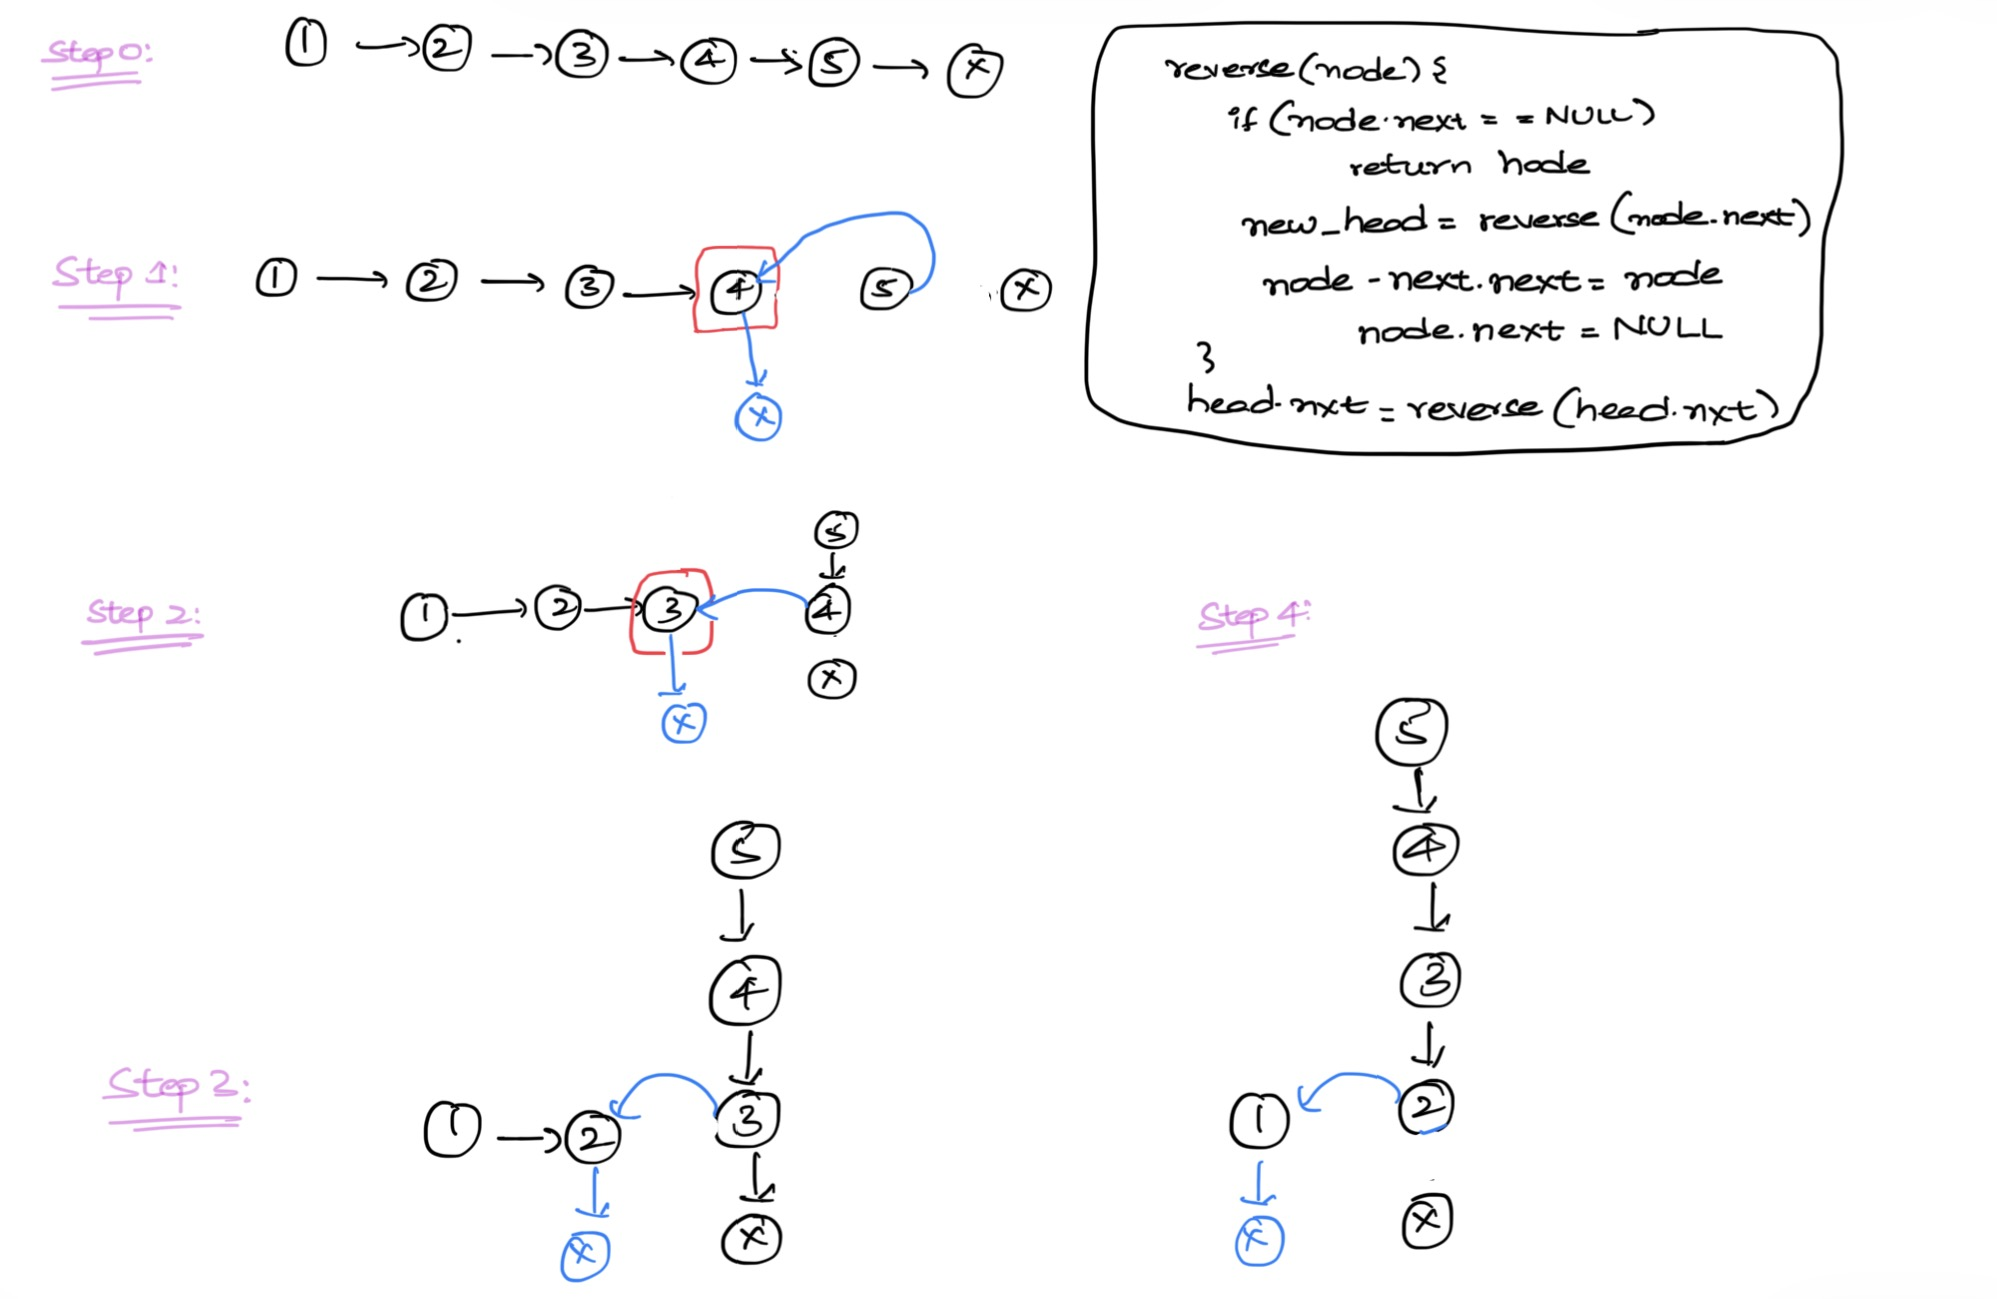

In [5]:
lst.reverse_recursive(True)
display(Image(filename='Reverse List Recursive.png'))

# Main Algorithms / Patterns

##### 1. Detect a Loop in Linked List

In [6]:
def hasCycle(head) -> bool:
    if head is None:
        return False
    slow = head
    fast = head.next
    while slow != fast:
        if fast is None or fast.next is None:
            return False
        slow = slow.next
        fast = fast.next.next
    return True


##### 2. Find a starting position in Linked List

In [7]:
def detectCycle(self, head: Optional[ListNode]) -> Optional[ListNode]:
    if head is None or head.next is None:
        return None
    slow, fast = head, head
    while fast.next and fast.next.next:
        slow = slow.next
        fast = fast.next.next

        if slow == fast:
            # cycle exists
            temp = head
            while slow != temp:
                slow = slow.next
                temp = temp.next
            return temp

    # cycle doesn't exists
    return None


##### 3. Length of the loop in Linked list

In [8]:
def findLengthOfLoop(head):
    slow, fast = head, head
    while fast and fast.next:
        fast = fast.next.next
        slow = slow.next
        if fast == slow:
            # loop
            length = 1
            fast = fast.next
            while fast != slow:
                fast = fast.next
                length += 1
            return length

    return 0


# Leetcode Problems

## Easy

##### 1. Palindrome Linked List

In [9]:
def isPalindrome(head) -> bool:

    if not head or not head.next:
        return True

    def middle(node):
        fast,slow = node, node
        while fast and fast.next:
            fast = fast.next.next
            slow = slow.next
        return slow

    # find middle
    middle_node = middle(head)

    # reverse second half
    prev, curr = None, middle_node
    while curr:
        tmp = curr.next
        curr.next = prev
        prev = curr
        curr = tmp

    # check isPalindrome
    temp1, temp2 = head, prev
    while temp2:
        if temp1.val != temp2.val:
            return False
        temp1 = temp1.next
        temp2 = temp2.next
    return True

##### 2. Odd Even Linked List

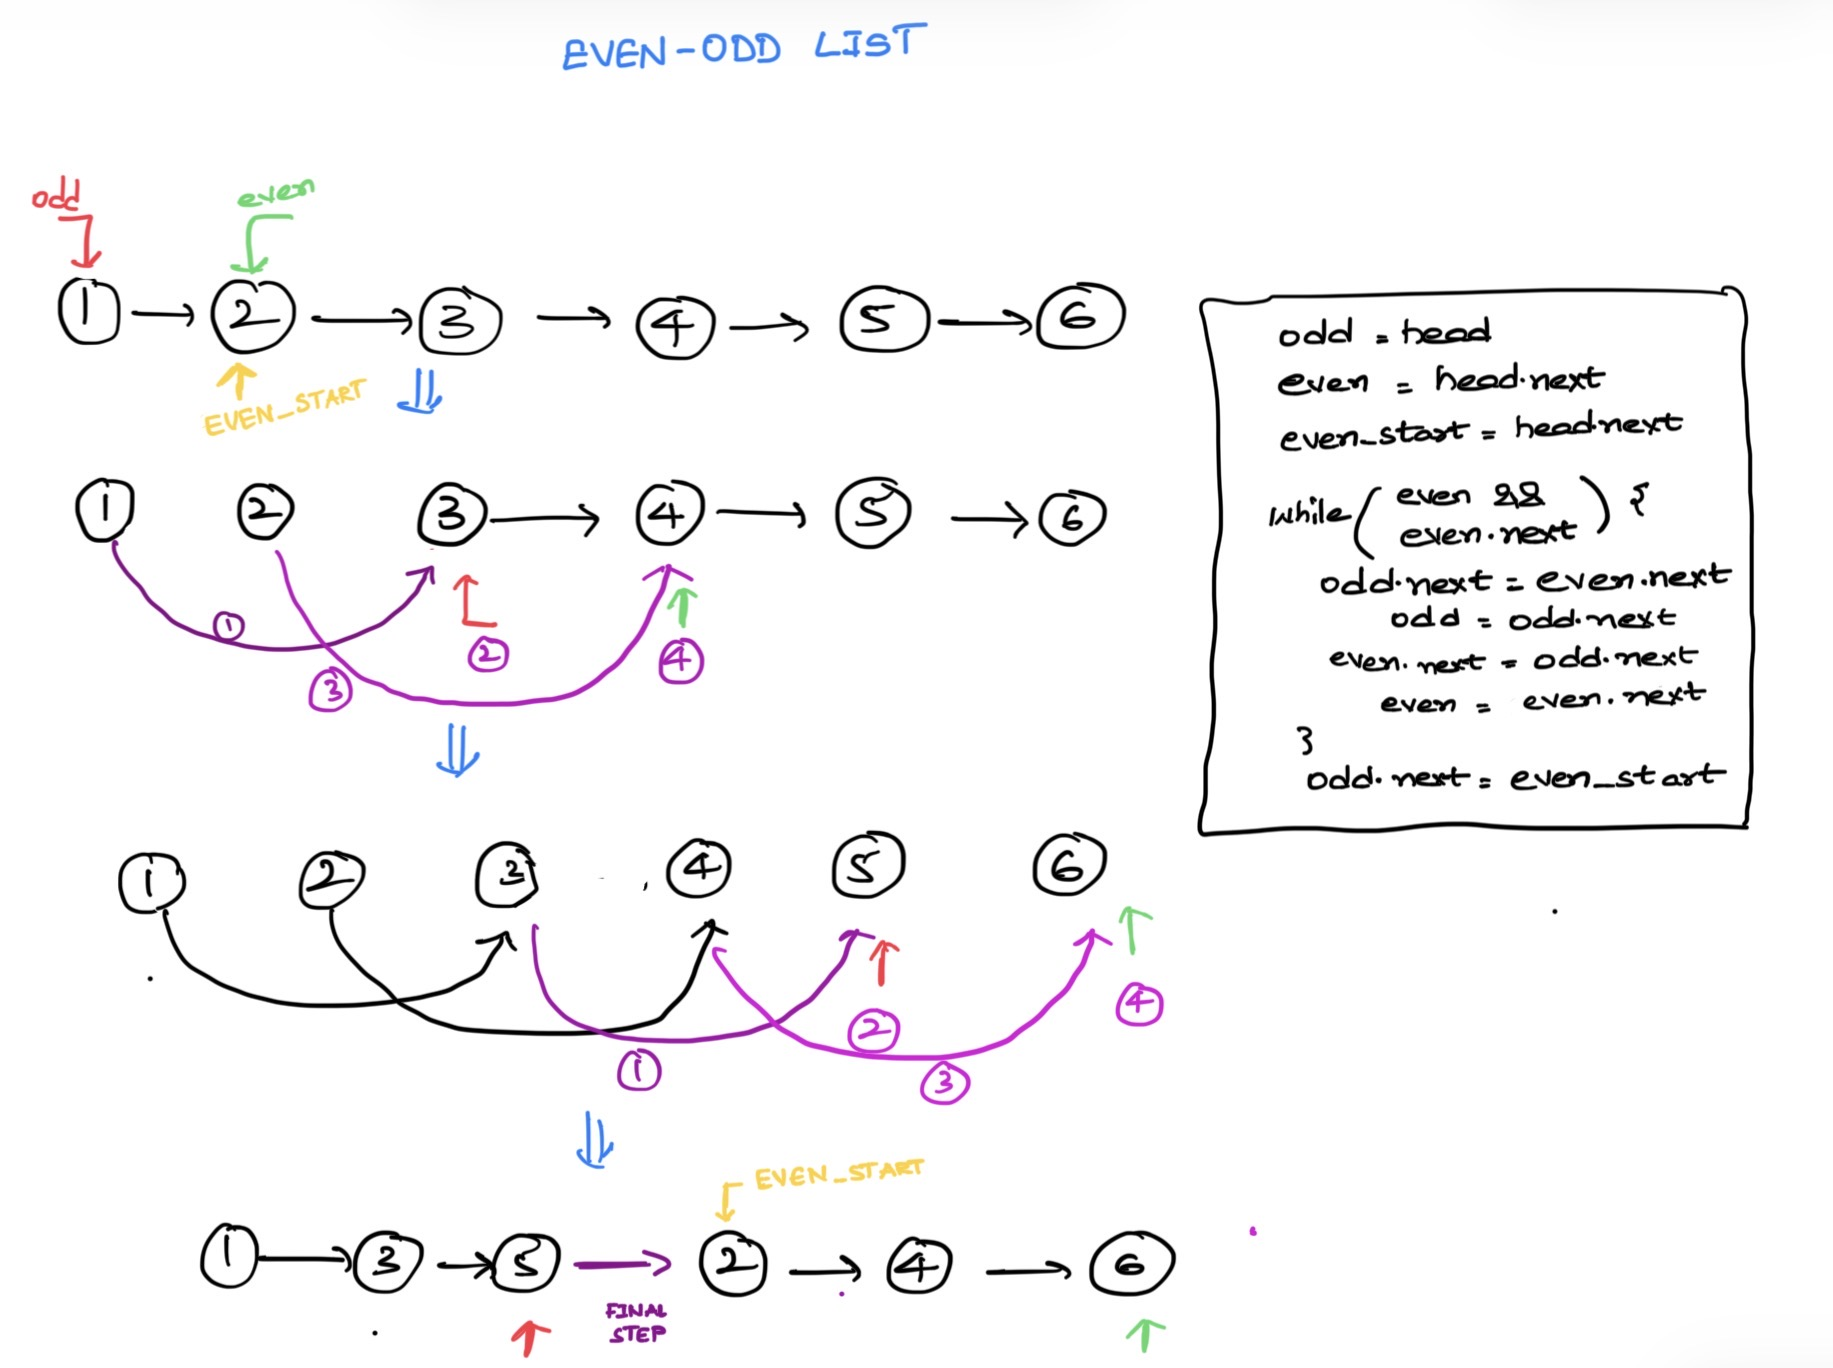

In [10]:
def oddEvenList(self, head: Optional[ListNode]) -> Optional[ListNode]:
    if head is None or head.next is None:
        return head
    odd, even = head, head.next
    even_start = head.next
    while even and even.next:
        odd.next = even.next
        odd = even.next
        even.next = odd.next
        even = even.next
    odd.next = even_start
    return head

display(Image(filename='even_odd_list.jpg'))

##### 3. Remove N-th node from the end of a Linked List

In [11]:
def removeNthFromEnd(head, n: int):
    fast, slow = head,head
    for _ in range(n):
        fast = fast.next

    # if fast is None, need to remove head
    if not fast:
        return head.next
        
    while fast and fast.next:
        fast = fast.next
        slow = slow.next
    slow.next = slow.next.next
    return head

##### 4. Delete the middle node of a Linked List

In [12]:
def deleteMiddle(head):
    if head is None or head.next is None:
        return None
    fast, slow = head, head
    prev_slow = head
    while fast and fast.next:
        fast = fast.next.next
        prev_slow = slow
        slow = slow.next
    prev_slow.next = prev_slow.next.next
    return head


##### 5. Merge Two Sorted Linked Lists

In [13]:
def mergeTwoLists(self, list1: Optional[ListNode], list2: Optional[ListNode]) -> Optional[ListNode]:
    dummy_node = ListNode(-1)
    prev = dummy_node
    while list1 and list2:
        if list1.val < list2.val:
            prev.next = list1
            list1 = list1.next
        else:
            prev.next = list2
            list2 = list2.next
        prev = prev.next
    if list1:
        prev.next = list1
    elif list2:
        prev.next = list2
    return dummy_node.next


##### 6. Remove Linked List Elements

In [14]:
def removeElements(self, head: Optional[ListNode], val: int) -> Optional[ListNode]:
    dummy_node = ListNode(-1,head)
    prev, curr = dummy_node, head
    while curr:
        if curr.val == val:
            curr = curr.next
            prev.next = curr
        else:
            prev = curr
            curr = curr.next
    return dummy_node.next

##### 7.Remove Duplicates from Sorted List

In [15]:
class Solution:
    def deleteDuplicates(self, head: Optional[ListNode]) -> Optional[ListNode]:
        dummy_node = ListNode(-1,head)
        prev, curr = dummy_node, head
        while curr and curr.next:
            while curr and curr.next and curr.val == curr.next.val:
                curr = curr.next
            prev.next = curr
            prev = prev.next
            curr = curr.next
        return dummy_node.next

##### 8. Delete Nodes

In [16]:
class Solution:
    def deleteNodes(self, head: Optional[ListNode], m: int, n: int) -> Optional[ListNode]:
        dummy_node = ListNode(-1,head)
        prev,curr = dummy_node, head

        while curr:
            i = m
            while i and curr:
                prev = curr
                curr = curr.next
                i -= 1
            j = n
            while j and curr:
                curr = curr.next
                j -= 1
            if prev:
                prev.next = curr
        return dummy_node.next

##### 9. Delete N Nodes After M Nodes of a Linked List

In [17]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, val=0, next=None):
#         self.val = val
#         self.next = next
class Solution:
    def deleteNodes(self, head: Optional[ListNode], m: int, n: int) -> Optional[ListNode]:
        dummy_node = ListNode(-1,head)
        prev,curr = dummy_node, head

        while curr:
            i = m
            while i and curr:
                prev = curr
                curr = curr.next
                i -= 1
            j = n
            while j and curr:
                curr = curr.next
                j -= 1
            if prev:
                prev.next = curr
        return dummy_node.next

# Medium

##### 1. Find intersection of Two Linked Lists

In [18]:
# Approach 1
class Solution:
    def getIntersectionNode(self, headA: ListNode, headB: ListNode) -> Optional[ListNode]:
        curr_a, curr_b = headA, headB
        len_a, len_b = 0, 0

        # it should atleast intersect at last node
        while curr_a.next:
            curr_a = curr_a.next
            len_a += 1
        while curr_b.next:
            curr_b = curr_b.next
            len_b += 1
        if curr_a != curr_b:
            # no intersection
            return None
        curr_a, curr_b = headA, headB
        while len_a > len_b:
            curr_a = curr_a.next
            len_a -= 1
        while len_b > len_a:
            curr_b = curr_b.next
            len_b -= 1

        while (curr_a != curr_b):
            curr_a = curr_a.next
            curr_b = curr_b.next
        return curr_a

# T(N) = O(M) + O(N) + O(abs(M-N)) + O(min(M,N)) ~ O(M+N)
# S(N) = O(1)
# Approach 2
class Solution:
    def getIntersectionNode(self, headA: ListNode, headB: ListNode) -> Optional[ListNode]:
        if not headA or not headB:
            return None
        a, b = headA, headB
        while a != b:
            if a:
                a = a.next
            else:
                a = headB
            if b:
                b = b.next
            else:
                b = headA
        return a

##### 2. Add 1 to a number represented as linked list

In [19]:
class Solution:
    def plusOne(self, head: ListNode) -> ListNode:
        def reverse(node):
            prev, curr = None, node
            while curr:
                temp = curr.next
                curr.next = prev
                prev = curr
                curr = temp
            return prev
        head = reverse(head)
        carry = 1
        ptr = head
        prev = None

        while ptr and carry:
            ptr.val += carry
            if ptr.val >= 10:
                carry = 1
                ptr.val -= 10
            else:
                carry = 0
            prev = ptr
            ptr = ptr.next

        if carry:
            prev.next = ListNode(carry)
        return reverse(head)

##### 3. Double a Number Represented as a Linked List

In [20]:
class Solution:
    def doubleIt(self, head: Optional[ListNode]) -> Optional[ListNode]: 
        def reverse(node):
            prev, curr = None, node
            while curr:
                temp = curr.next
                curr.next = prev
                prev = curr
                curr = temp
            return prev

        head = reverse(head)
        prev, ptr = None, head
        carry = 0
        while ptr:
            ptr.val = ptr.val * 2 + carry
            if ptr.val >= 10:
                carry = 1
                ptr.val -= 10
            else:
                carry = 0
            prev = ptr
            ptr = ptr.next
        if carry:
            prev.next = ListNode(carry)
        return reverse(head)

##### 4. Add two numbers represented as Linked Lists

In [21]:
# class Solution:
#     def addTwoNumbers(self, l1: Optional[ListNode], l2: Optional[ListNode]) -> Optional[ListNode]:
#         parity = 0
#         dummy_node = ListNode()
#         curr = dummy_node
#         ptr1, ptr2 = l1, l2
#         while l1 and l2:
#             s = l1.val + l2.val + parity
#             if s > 9:
#                 parity = 1
#                 s -= 10
#             else:
#                 parity = 0
#             curr.next = ListNode(s)
#             curr = curr.next
#             l1 = l1.next
#             l2 = l2.next
#         while l1:
#             s = l1.val + parity
#             if s > 9:
#                 parity = 1
#                 s -= 10
#             else:
#                 parity = 0
#             curr.next = ListNode(s)
#             curr = curr.next
#             l1 = l1.next
#         while l2:
#             s = l2.val + parity
#             if s > 9:
#                 parity = 1
#                 s -= 10
#             else:
#                 parity = 0
#             curr.next = ListNode(s)
#             curr = curr.next
#             l2 = l2.next
#         if parity:
#             curr.next = ListNode(parity)
#             curr = curr.next
#         return dummy_node.next

class Solution:
    def addTwoNumbers(self, l1: Optional[ListNode], l2: Optional[ListNode]) -> Optional[ListNode]:
        parity = 0
        dummy_node = ListNode()
        curr = dummy_node
        while l1 or l2 or parity:
            s = (l1.val if l1 else 0) + (l2.val if l2 else 0) + parity
            if s > 9:
                parity = 1
                s -= 10
            else:
                parity = 0
            curr.next = ListNode(s)
            curr = curr.next
            l1 = l1.next if l1 else None
            l2 = l2.next if l2 else None
        return dummy_node.next


##### 5.Add Two Numbers II

In [22]:
class Solution:
    def addTwoNumbers(self, l1: Optional[ListNode], l2: Optional[ListNode]) -> Optional[ListNode]:
        
        def reverse(node):
            prev, curr = None, node
            while curr:
                temp = curr.next
                curr.next = prev
                prev = curr
                curr = temp
            return prev
        
        l1 = reverse(l1)
        l2 = reverse(l2)

        parity = 0
        dummy_node = ListNode()
        curr = dummy_node
        while l1 or l2 or parity:
            s = (l1.val if l1 else 0) + (l2.val if l2 else 0) + parity
            if s > 9:
                parity = 1
                s -= 10
            else:
                parity = 0
            curr.next = ListNode(s)
            curr = curr.next
            l1 = l1.next if l1 else None
            l2 = l2.next if l2 else None
        return reverse(dummy_node.next)

##### 6. Rotate a Linked List

In [23]:
class Solution:
    def rotateRight(self, head: Optional[ListNode], k: int) -> Optional[ListNode]:
        if not head or not head.next:
            return head
        n = 0
        curr = head
        tail = None
        while curr:
            n += 1
            tail = curr
            curr = curr.next
        k = k % n
        tail.next = head
        cut = n - k - 1

        new_head = None
        while cut:
            head = head.next
            cut -= 1
        new_head = head.next
        head.next = None
        return new_head

##### 7. Reorder the list 

L0 → L1 → … → Ln - 1 → Ln to L0 → Ln → L1 → Ln - 1 → L2 → Ln - 2 → …

In [24]:
class Solution:
    def reorderList(self, head: Optional[ListNode]) -> None:
        """
        Do not return anything, modify head in-place instead.
        """
        if not head or not head.next:
            return
        
        # 1. reverse 2nd half
        # 2. merge 1st and 2nd half

        slow, fast = head, head
        while fast and fast.next:
            fast = fast.next.next
            slow = slow.next

        
        prev, curr = None, slow.next
        slow.next = None             # cut the list to 2 halves

        while curr:
            temp = curr.next
            curr.next = prev
            prev = curr
            curr = temp

        ptr1, ptr2 = head, prev

        while ptr2:
            tmp1, tmp2 = ptr1.next, ptr2.next
            ptr1.next = ptr2
            ptr2.next = tmp1
            ptr1 = tmp1
            ptr2 = tmp2


##### 8. Swap Nodes in Pairs

In [25]:
class Solution:
    def swapPairs(self, head: Optional[ListNode]) -> Optional[ListNode]:
        dummy_node = ListNode(-1,head)
        prev, curr = dummy_node, head

        while curr and curr.next:
            temp = curr.next.next
            prev.next = curr.next
            curr.next.next = curr
            curr.next = temp

            prev = curr
            curr = temp
        
        return dummy_node.next


##### 9. Find Duplicate in [1,n] (287. Find the Duplicate Number)

##### 10. Remove Nodes From Linked List

In [26]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, val=0, next=None):
#         self.val = val
#         self.next = next
class Solution:
    def removeNodes(self, head: Optional[ListNode]) -> Optional[ListNode]:
        
        def reverse(node):
            prev, curr = None, node
            while curr:
                temp = curr.next
                curr.next = prev
                prev = curr
                curr = temp
            return prev

        new_head = reverse(head)
        dummy_node = ListNode(-1,new_head)
        prev, curr = dummy_node, dummy_node.next

        while curr:
            if curr.val >= prev.val:
                prev.next = curr
                prev = curr
            curr = curr.next
        prev.next = None
        return reverse(dummy_node.next)
            

##### 11. Delete Nodes From Linked List Present in Array

In [27]:
class Solution:
    def modifiedList(self, nums: List[int], head: Optional[ListNode]) -> Optional[ListNode]:
        st = set(nums)
        dummy_node = ListNode(-1,head)
        prev, curr = dummy_node, dummy_node.next
        while curr:
            if curr.val not in st:
                prev.next = curr
                prev = prev.next
            curr = curr.next
        prev.next = None
        return dummy_node.next

##### 12. Swapping Nodes in a Linked List

In [28]:
class Solution:
    def swapNodes(self, head: Optional[ListNode], k: int) -> Optional[ListNode]:
        fast, slow = head, head
        curr = ListNode(-1,head)
        for _ in range(k):
            fast = fast.next
            curr = curr.next
        while fast:
            fast = fast.next
            slow = slow.next
        curr.val, slow.val = slow.val, curr.val
        return head

# Medium - Hard

##### 1. Insert into a Sorted Circular Linked List


In [29]:
class Solution:
    def insert(self, head: 'Optional[Node]', insertVal: int) -> 'Node':
        new_node = Node(insertVal)

        if not head:
            new_node.next = new_node
            return new_node

        prev, curr = head, head.next
        
        while True:
            # normal position
            if prev.val <= insertVal <= curr.val:
                break
            
            # max -> min
            if prev.val > curr.val:
                if insertVal >= prev.val or insertVal <= curr.val:
                    break
            
            prev = curr
            curr = curr.next

            # all values are same or no spot found
            if prev == head:
                break
            
        prev.next = new_node
        new_node.next = curr

        return head


##### 2. Partition List

In [30]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, val=0, next=None):
#         self.val = val
#         self.next = next
class Solution:
    def partition(self, head: Optional[ListNode], x: int) -> Optional[ListNode]:
        dummy1 = ListNode(-1)
        dummy2 = ListNode(-1)

        ptr1, ptr2 = dummy1, dummy2
        while head:
            if head.val < x:
                ptr1.next = head
                ptr1 = ptr1.next
            else:
                ptr2.next = head
                ptr2 = ptr2.next
            head = head.next
        ptr2.next = None
        ptr1.next = dummy2.next
        return dummy1.next

##### 3. Insertion Sort - LinkedList

In [31]:
class Solution:
    def insertionSortList(self, head: Optional[ListNode]) -> Optional[ListNode]:
        dummy_node = ListNode(-1)
        prev, curr = dummy_node, head
        while curr:
            prev = dummy_node
            while prev.next and prev.next.val <= curr.val:
                prev = prev.next

            temp = curr.next
            curr.next = prev.next
            prev.next = curr
            curr = temp
        
        return dummy_node.next


# Design Questions

##### 1. Design Linkedlist (707)

In [ ]:
class DoubleNode:
    def __init__(self, val=0, prev=None, next=None):
        self.val = val
        self.prev = prev
        self.next = next

class MyLinkedList:

    def __init__(self):
        self.head = DoubleNode(-1)
        # first node pointer
        self.head.next = None
        # tail pointer
        self.head.prev = None
        self.len = 0

    def get(self, index: int) -> int:
        if index >= self.len or index < 0:
            return -1
        curr = self.head.next
        while index:
            curr = curr.next
            index -= 1
        return curr.val

    def addAtHead(self, val: int) -> None:
        new_node = DoubleNode(val, self.head, self.head.next)
        if self.head.next:
            self.head.next.prev = new_node
        self.head.next = new_node
        if self.len == 0:
            self.head.prev = new_node
        self.len += 1

    def addAtTail(self, val: int) -> None:
        if self.len == 0:
            self.addAtHead(val)
            return
        new_node = DoubleNode(val, self.head.prev, None)
        self.head.prev.next = new_node
        self.head.prev = new_node
        self.len += 1

    def addAtIndex(self, index: int, val: int) -> None:
        if index > self.len or index < 0:
            return
        curr = self.head
        while index:
            curr = curr.next
            index -= 1
        new_node = DoubleNode(val, curr, curr.next)
        if curr.next:
            curr.next.prev = new_node
        curr.next = new_node
        if new_node.next is None:
            self.head.prev = new_node
        self.len += 1

    def deleteAtIndex(self, index: int) -> None:
        if index >= self.len or index < 0:
            return
        curr = self.head
        while index:
            curr = curr.next
            index -= 1
        if curr.next:
            curr.next = curr.next.next
            if curr.next:
                curr.next.prev = curr
        if curr.next is None:
            self.head.prev = curr
        self.len -= 1



# Your MyLinkedList object will be instantiated and called as such:
# obj = MyLinkedList()
# param_1 = obj.get(index)
# obj.addAtHead(val)
# obj.addAtTail(val)
# obj.addAtIndex(index,val)
# obj.deleteAtIndex(index)

# Hard

##### 1. Merge Sort - LinkedList - (Sort List Leetcode)

In [32]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, val=0, next=None):
#         self.val = val
#         self.next = next
class Solution:
    def merge_list(self, list1, list2):
        dummy_node = ListNode(-1)
        prev = dummy_node
        while list1 and list2:
            if list1.val < list2.val:
                prev.next = list1
                list1 = list1.next
            else:
                prev.next = list2
                list2 = list2.next
            prev = prev.next
        if list1:
            prev.next = list1
        else:
            prev.next = list2
        return dummy_node.next
            
    
    def sortList(self, head: Optional[ListNode]) -> Optional[ListNode]:
        # merge sort on linked list
        if not head or not head.next:
            return head
        # get the middle node, divide and merge
        slow, fast = head, head.next
        while fast and fast.next:
            slow = slow.next
            fast = fast.next.next
        middle = slow.next
        # break the link 
        slow.next = None
        # divide
        left = self.sortList(head)
        right = self.sortList(middle)
        return self.merge_list(left,right)

##### 2. Reverse Linked List in groups of Size K

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


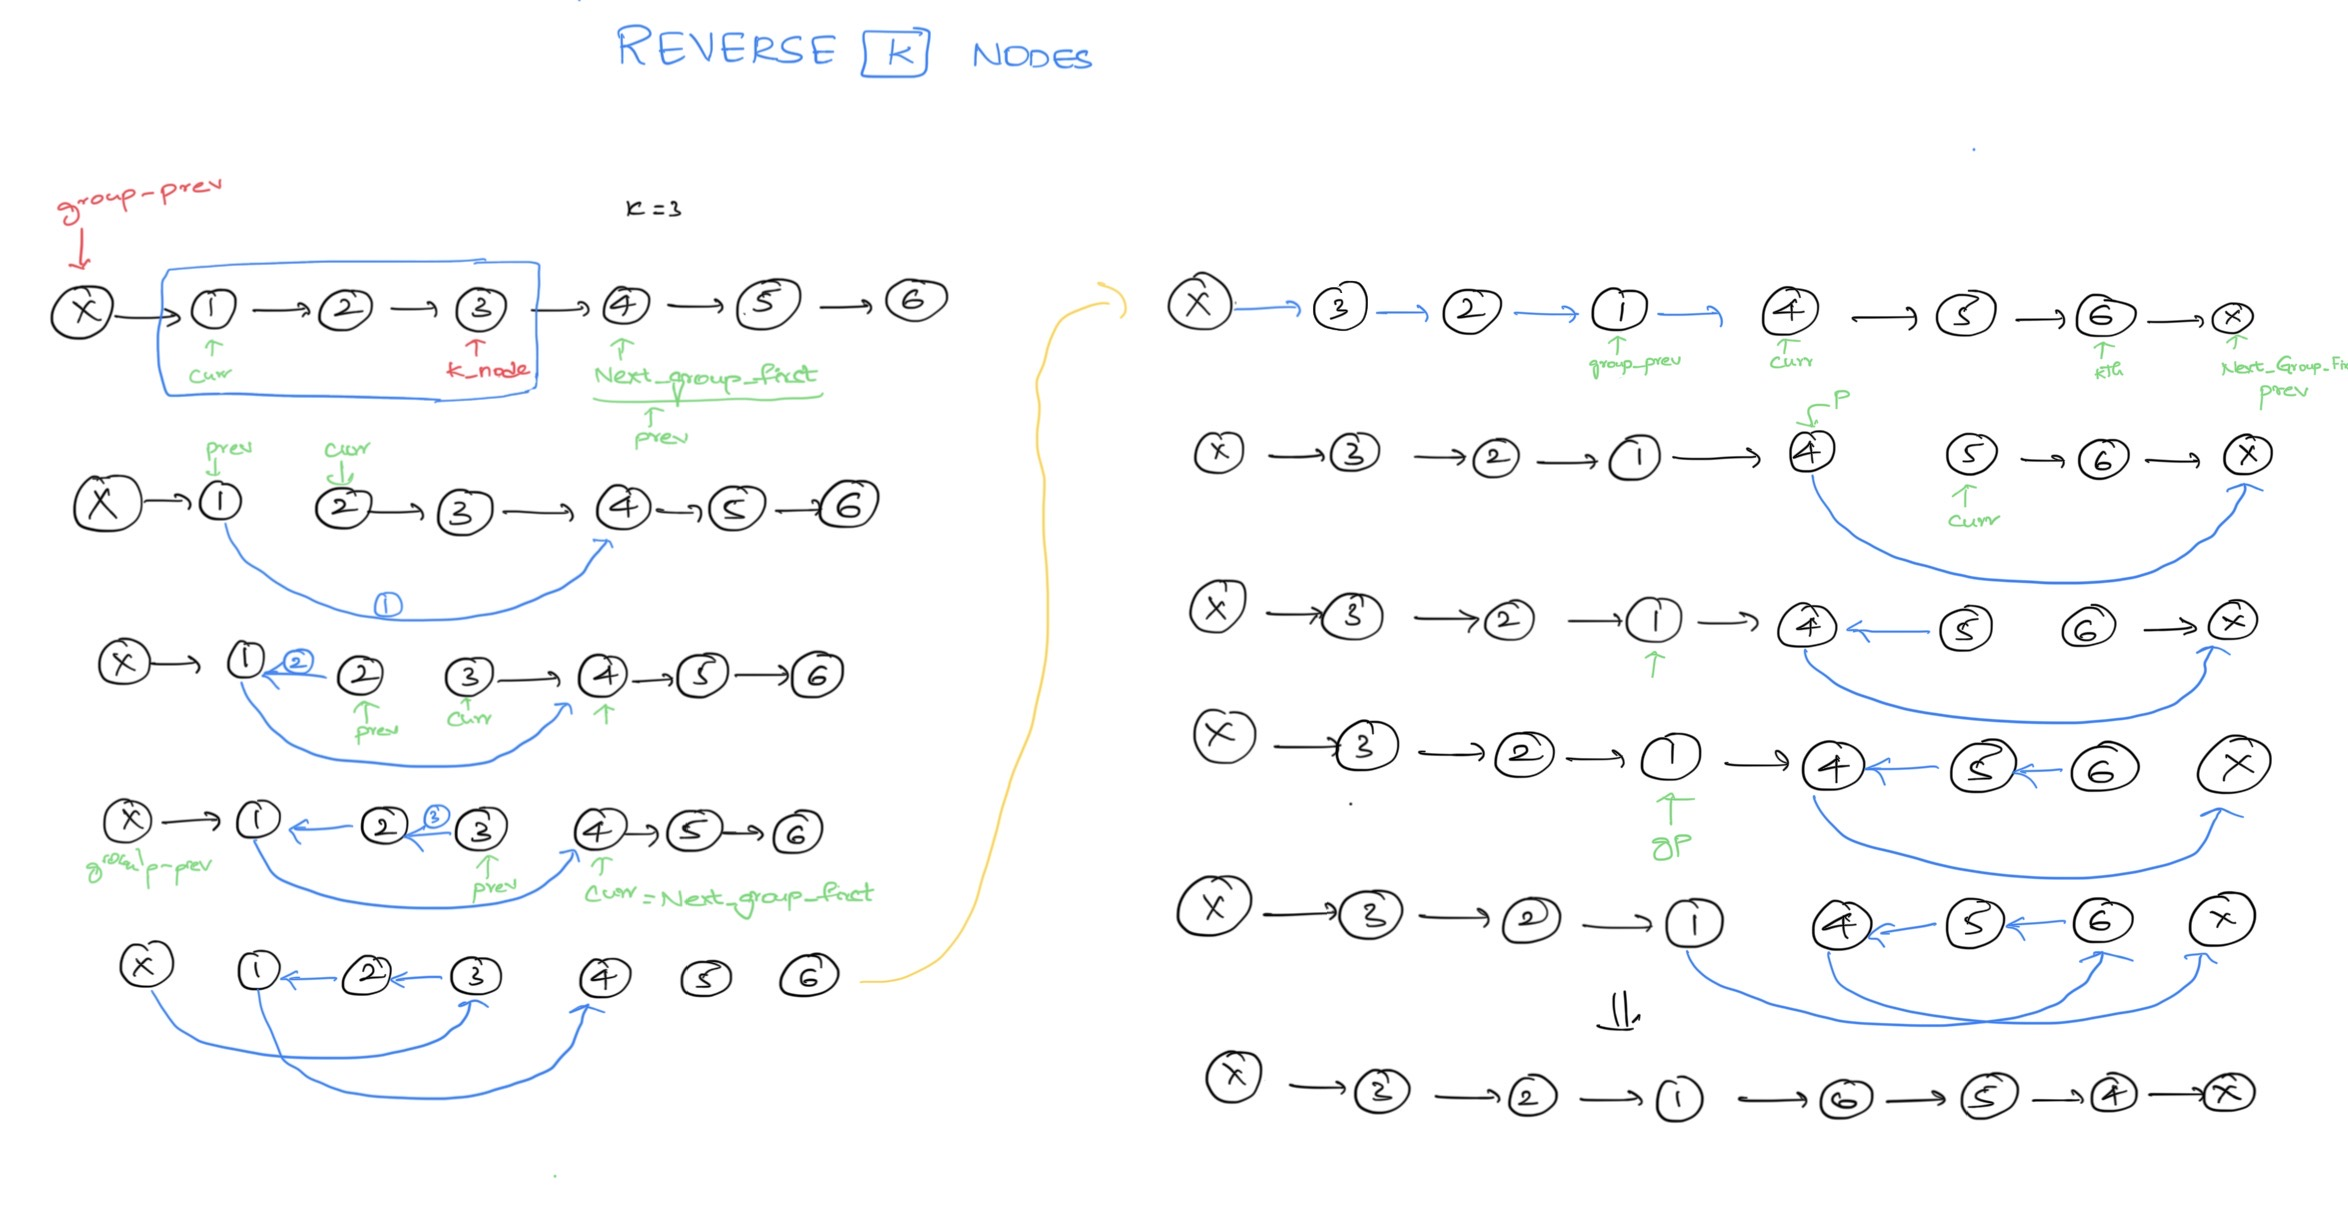

In [34]:
class Solution:
    def reverseKGroup(self, head: Optional[ListNode], k: int) -> Optional[ListNode]:
        dummy_node = ListNode(-1, head)

        def get_kth_node(node, k):
            # node is previous to the group starting
            while node and k:
                node = node.next
                k -= 1
            return node

        group_prev = dummy_node
        while True:
            kth_node = get_kth_node(group_prev,k)
            if not kth_node:
                break

            next_group_first = kth_node.next
            prev = next_group_first
            curr = group_prev.next

            while curr != next_group_first:
                temp = curr.next
                curr.next = prev
                prev = curr
                curr = temp

            temp = group_prev.next
            group_prev.next = kth_node
            group_prev = temp
            
        return dummy_node.next


display(Image(filename='Reverse K Nodes.jpeg'))

##### 4. Copy List with Random Pointer (Leetcode - 138)